# Figure 2A. Species accumulation curve

In [1]:
# map from original id to species
import polars as pl

seqhasher = pl.read_csv('../figure_1/uhvdb_human_metag_results/2026-03-26-2_outputs/dereplicate/hq_hc_viruses_seqhasher.tsv.gz', separator='\t').unique('original_id')
uhvdb_mapping = pl.concat([
    pl.read_csv('../figure_1/uhvdb_virus_db_results/uhvdb_2026-03-26/uhvdb_mapping.tsv.gz', separator='\t'),
    pl.read_csv('../figure_1/uhvdb_human_metag_results/2026-03-26-2_outputs/dereplicate/new_hq_hc_viruses_mapping.tsv.gz', separator='\t')
])
seqhash_reps = seqhasher.filter(pl.col('original_id').is_in(set(uhvdb_mapping['original_id']))).unique('original_id').rename({'original_id':'seqhash_rep'})
uhvdb_source_meta = pl.read_csv('../figure_1/uhvdb_final_metadata.tsv', separator='\t')
genomovar_info = pl.read_csv('../figure_1/uhvdb_human_metag_results/2026-03-26-2_outputs/genomovars_cluster/hq_hc_genomovars_info.tsv.gz', separator='\t')
uhvdb_species_info = pl.read_csv('../figure_1/uhvdb_human_metag_results/2026-03-26-2_outputs/species_cluster/hq_hc_species_info.tsv.gz', separator='\t')
aaicluster = pl.read_csv('../figure_1/uhvdb_human_metag_results/2026-03-26-2_outputs/aaicluster/hq_hc_species_aai_clusters.tsv.gz', separator='\t')

combined = (
    uhvdb_source_meta
        .join(seqhasher.unique('original_id'), left_on='seq_name', right_on='original_id', how='left')
        .join(seqhasher.with_columns(pl.col('original_id').str.extract(r"^(.*)\|provirus", group_index=1).fill_null(pl.col("original_id"))), left_on='seq_name', right_on='original_id', how='left')
        .with_columns(
            pl.when(pl.col('hash').is_not_null()).then(pl.col('hash')).otherwise(pl.col('hash_right')).alias('hash')
        )
        .join(seqhash_reps, on='hash', how='left')
        .join(uhvdb_mapping.unique('original_id'), left_on='seqhash_rep', right_on='original_id', how='left')
        .join(genomovar_info[['uhvdb_id', 'votu_rep']], left_on='new_id', right_on='uhvdb_id', how='left').rename({'votu_rep':'genomovar_rep'})
        .join(uhvdb_species_info[['uhvdb_id', 'votu_rep']], left_on='genomovar_rep', right_on='uhvdb_id', how='left')
        .join(aaicluster, left_on='votu_rep', right_on='uhvdb_id', how='left')
        .unique('seq_name')
)
combined.write_csv('uhvdb_cluster_mapping.tsv', separator='\t')

In [2]:
### Load species cluster info
import polars as pl
uhvdb_species_info = pl.read_csv('../figure_1/uhvdb_human_metag_results/2026-03-26-2_outputs/species_cluster/hq_hc_species_info.tsv.gz', separator='\t')

In [3]:
print("Num UHVDB species:", uhvdb_species_info.unique('votu_rep').height)
print("Num species reps with TRs:",
    uhvdb_species_info
        .filter((pl.col('completeness_method').str.contains('TR')))
        .unique('votu_rep').height
)

Num UHVDB species: 199442
Num species reps with TRs: 71271


In [4]:
import polars as pl
import numpy as np

# ---------------------------------------------------------
# 1. Define the Accumulation Function
# ---------------------------------------------------------
def calculate_complex_accumulation(df: pl.DataFrame, species_col: str, n_permutations: int = 100) -> pl.DataFrame:
    results = []
    
    for i in range(n_permutations):
        # Shuffle the database
        shuffled = df.sample(fraction=1.0, shuffle=True, seed=i)
        
        # Calculate all three cumulative metrics simultaneously
        accum = shuffled.select(
            genomes_sampled = pl.int_range(1, pl.len() + 1),
            
            # 1. Total Species Count
            total_species = pl.col(species_col).is_first_distinct().cum_sum(),
            
            # 2. Non-Singleton Species (Triggers exactly on the 2nd appearance)
            non_singletons = (
                pl.col(species_col).cum_count().over(species_col) == 2
            ).cum_sum(),
            
            # 3. TR-Containing Species (Triggers on the 1st genome of a species that has a TR)
            tr_species = (
                pl.col("completeness_method").str.contains("TR") & 
                (pl.col("completeness_method").str.contains("TR").cast(pl.UInt32).cum_sum().over(species_col) == 1)
            ).cum_sum()
        )
        results.append(accum)
        
    all_permutations = pl.concat(results)
    
    # Aggregate Means (Min/Max omitted here for cleaner plotting, but easily added)
    final_curve = (
        all_permutations
        .group_by("genomes_sampled")
        .agg(
            mean_total = pl.col("total_species").mean(),
            mean_non_singletons = pl.col("non_singletons").mean(),
            mean_tr = pl.col("tr_species").mean()
        )
        .sort("genomes_sampled")
    )
    
    return final_curve

# ---------------------------------------------------------
# 2. Execute and View Results
# ---------------------------------------------------------
accumulation_curve = calculate_complex_accumulation(uhvdb_species_info, species_col="cluster_id", n_permutations=50)

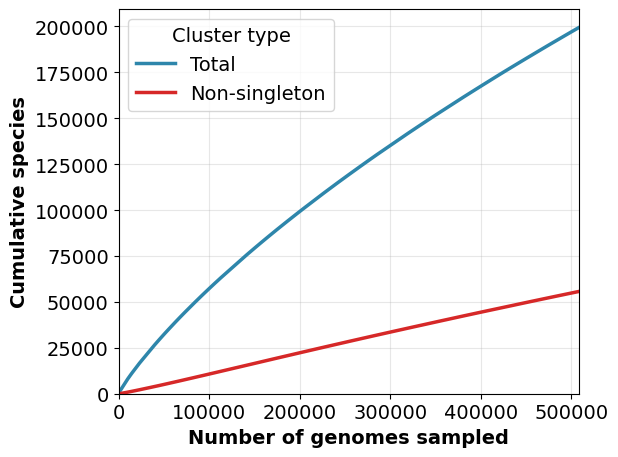

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.reset_orig()
plt.rcParams.update({'font.size': 14})

# ---------------------------------------------------------
# 3. Plot with Seaborn & Matplotlib
# ---------------------------------------------------------
# Extract columns to flat numpy arrays for plotting
x = accumulation_curve["genomes_sampled"].to_numpy()
y_total = accumulation_curve["mean_total"].to_numpy()
y_non_sing = accumulation_curve["mean_non_singletons"].to_numpy()
y_tr = accumulation_curve["mean_tr"].to_numpy()

# Plot all three metrics
# plt.figure(figsize=(7, 6))
plt.grid(True, alpha=0.3)
sns.lineplot(x=x, y=y_total, color="#2E86AB", linewidth=2.5, label="Total", errorbar=lambda x: (x.min(), x.max()))
sns.lineplot(x=x, y=y_non_sing, color="#D62828", linewidth=2.5, label="Non-singleton", errorbar=lambda x: (x.min(), x.max()))
# sns.lineplot(x=x, y=y_tr, color="#F5D547", linewidth=2.5, label="Complete representatives", errorbar=lambda x: (x.min(), x.max()))

# Formatting
plt.xlabel("Number of genomes sampled", fontdict={'fontweight': 'bold'})
plt.ylabel("Cumulative species", fontdict={'fontweight': 'bold'})
plt.xlim(0, max(x))
plt.ylim(0, max(y_total) * 1.05)
plt.legend(title='Cluster type', loc="upper left")

plt.tight_layout()
plt.show()

In [6]:
import polars as pl
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Species accumulation curves split by body site
# ---------------------------------------------------------
body_site_species_df = (
    combined
    .select(["seqhash_rep", "body_site", "votu_rep"])
    .filter(
        pl.col("body_site").is_not_null()
        & (pl.col("body_site") != "Other")
        & pl.col("votu_rep").is_not_null()
    )
    .unique()
)

body_sites = body_site_species_df["body_site"].unique().to_list()
n_reps = 50
n_points = 100
results = []

for body_site in body_sites:
    site_df = body_site_species_df.filter(pl.col("body_site") == body_site)
    n_units = site_df.height
    if n_units == 0:
        continue

    subset_sizes = np.unique(np.linspace(1, n_units, min(n_points, n_units), dtype=int))

    for rep in range(n_reps):
        perm_units = site_df.sample(fraction=1.0, shuffle=True, seed=rep).with_row_index("idx")
        seen_species = set()
        prev_n = 0

        for n in subset_sizes:
            current = perm_units.filter((pl.col("idx") >= prev_n) & (pl.col("idx") < n))
            seen_species.update(current["votu_rep"].to_list())
            prev_n = n

            results.append({
                "body_site": body_site,
                "subset": int(n),
                "replicate": rep,
                "species": len(seen_species),
            })

species_by_body_site_curve = (
    pl.from_dicts(results)
    .group_by(["body_site", "subset"])
    .agg([
        pl.col("species").mean().alias("mean_species"),
        pl.col("species").min().alias("min_species"),
        pl.col("species").max().alias("max_species"),
    ])
    .sort(["body_site", "subset"])
)

/tmp/ipykernel_54242/930009841.py:44: MatplotlibDeprecationWarning: Since Matplotlib 3.10 indicate_inset_[zoom] returns a single InsetIndicator artist with a rectangle property and a connectors property.  From 3.12 it will no longer be possible to unpack the return value into two elements.
  rect, connectors = ax.indicate_inset_zoom(axins, edgecolor="black", linewidth=2.5)


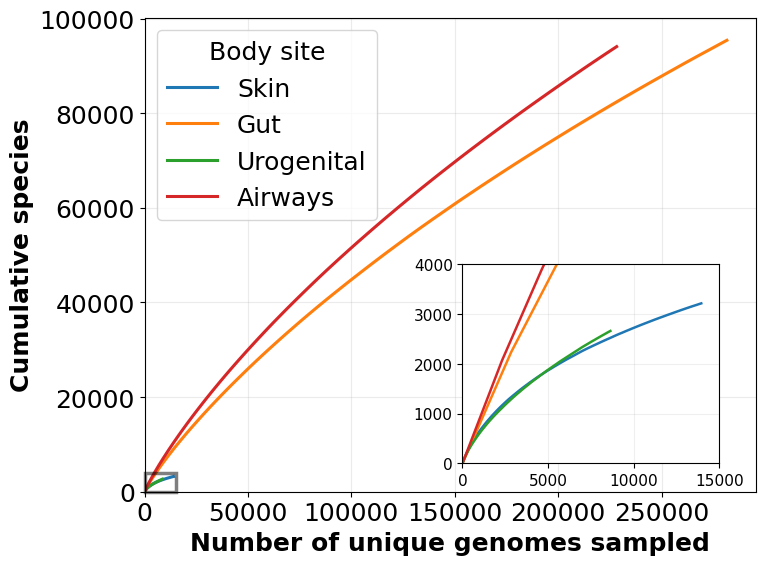

In [7]:
plt.rcParams.update({'font.size': 18})
site_order = [s for s in ["Skin", "Gut", "Urogenital", "Airways"] if s in species_by_body_site_curve["body_site"].unique().to_list()]
colors = {
    "Skin": "#1f77b4",
    "Gut": "#ff7f0e",
    "Urogenital": "#2ca02c",
    "Airways": "#d62728",
}

fig, ax = plt.subplots(figsize=(8, 6))
for body_site in site_order:
    d = species_by_body_site_curve.filter(pl.col("body_site") == body_site).sort("subset")
    x = d["subset"].to_numpy()
    y_mean = d["mean_species"].to_numpy()
    y_min = d["min_species"].to_numpy()
    y_max = d["max_species"].to_numpy()
    c = colors.get(body_site, None)

    ax.fill_between(x, y_min, y_max, color=c, alpha=0.15, linewidth=0)
    ax.plot(x, y_mean, color=c, lw=2.2, label=body_site)

ax.set_xlabel("Number of unique genomes sampled", fontdict={'fontweight': 'bold'})
ax.set_ylabel("Cumulative species", fontdict={'fontweight': 'bold'})
ax.legend(title="Body site", loc="upper left")
ax.grid(True, alpha=0.25)
ax.set_xlim(0, max(species_by_body_site_curve["subset"].to_list()) * 1.05)
ax.set_ylim(0, max(species_by_body_site_curve["max_species"].to_list()) * 1.05)

# Inset zoomed to x=0-15000 and y=0-4000
axins = ax.inset_axes([0.52, 0.06, 0.42, 0.42])
for body_site in site_order:
    d = species_by_body_site_curve.filter(pl.col("body_site") == body_site).sort("subset")
    x = d["subset"].to_numpy()
    y_mean = d["mean_species"].to_numpy()
    c = colors.get(body_site, None)
    axins.plot(x, y_mean, color=c, lw=1.8)

axins.set_xlim(0, 15000)
axins.set_ylim(0, 4000)
axins.grid(True, alpha=0.2)
axins.tick_params(labelsize=11)

# Make the inset box bolder
rect, connectors = ax.indicate_inset_zoom(axins, edgecolor="black", linewidth=2.5)
rect.set_linewidth(2.5)
rect.set_edgecolor("black")
for conn in connectors:
    conn.set_linewidth(2.0)
    conn.set_color("black")

plt.tight_layout()
plt.show()